# Experiment 1.2 — Direct weighted-event temporal-scale ablation with Event-CNN-L

## Research question

**At what temporal scale does the 15-channel encoded event representation carry letter-discriminative information?**

This is the Phase-A experiment most directly relevant to the later SNN design, because the perturbation is applied to the same 15 weighted event channels that will be supplied to the SNN.

### Data flow

`action0/action1 combination roots → paddedSpikeIMU → channels 0:15 [T,15] → temporal block shuffle → Event-CNN-L → frozen embedding → linear probe → test metrics`

`Event-CNN-L` keeps the repository CNN-L temporal topology (64→128→256→256, kernels 7/5/5/3, strides 1/2/2/1, masked global average pooling) and changes only the first-layer input count from 3 to 15.

## Perturbation semantics

For each sample, a block is a `[block_time, 15]` matrix. Blocks are permuted as units. **Channels are never shuffled independently.** This preserves every event amplitude, all simultaneous cross-channel activation at each timestep, and exact ordering inside each block, while destroying order between blocks.

## Interpretation for architecture design

- Recovery by ~50–100 ms supports a local multi-timescale front end and weakens the case for long recurrent memory.
- Recovery by ~100–300 ms supports an intermediate temporal integration stage.
- A substantial gap at 500 ms supports testing long-memory mechanisms (longer synaptic traces and/or recurrence) in later phases.

## Controls

As in Experiment 1.1, every condition is retrained from scratch; all five master seeds reuse one fixed user-disjoint split controlled by `SPLIT_SEED`; padding is excluded; and remaining stochasticity is derived from the declared master seeds.


In [12]:
from pathlib import Path
import hashlib
import json
import os
import random
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torch import nn
from torch.utils.data import Dataset, DataLoader

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, confusion_matrix


def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "snn").is_dir() and (candidate / "notebooks").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate writingRing repository root from current working directory")

REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from snn.accel_reconstruction_eval.datasets import load_acceleration_data

print("Repository root:", REPO_ROOT)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Repository root: /home/ted/project/writingring-viz
PyTorch: 2.11.0+cu130
CUDA available: True


## 1. Configuration

In [13]:
# -----------------------------------------------------------------------------
# USER CONFIGURATION
# -----------------------------------------------------------------------------
# Point these to the two *combination* directories, using the same convention as
# notebooks/experiment_C_frequency_benchmark_sweep.ipynb. The repository loader
# accepts either the dataset root or its segmentation_padded child.
ACTION0_COMBINATION_DIR = REPO_ROOT / "outputs/action0_wavelets_1_2_4_8_16"
ACTION1_COMBINATION_DIR = REPO_ROOT / "outputs/action1_wavelets_1_2_4_8_16"
DATASET_ROOTS = [ACTION0_COMBINATION_DIR, ACTION1_COMBINATION_DIR]

# Exactly five master seeds. Each master seed controls model init, DataLoader
# order, linear probe, and every shuffle permutation through derived
# deterministic sub-seeds.
SEEDS = (11, 23, 37, 53, 71)
assert len(SEEDS) == 5 and len(set(SEEDS)) == 5
# Fixed user-split seed shared across Experiments 1.1–1.3.
SPLIT_SEED: int = 12345

# Ordered labels to retain after user exclusion; None keeps every label.
INCLUDED_LABELS: tuple[str, ...] | None = ("A", "B", "C", "D", "E", "X", "G", "H", "I", "J", "K", "L")

TRAIN_FRACTION = 0.70
VAL_FRACTION = 0.15
BATCH_SIZE = 64
NUM_WORKERS = 0
NUM_EPOCHS = 50
EARLY_STOPPING_PATIENCE = 8
LEARNING_RATE = 5e-4
WEIGHT_DECAY = 0.0
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Primary Phase-A temporal conditions. At 200 Hz: 1 sample = 5 ms.
BLOCK_DURATIONS_MS = (5, 50, 100, 200, 500)
CONDITIONS = tuple(f"shuffle_{ms}ms" for ms in BLOCK_DURATIONS_MS) + ("original",)

print("Dataset roots:")
for root in DATASET_ROOTS:
    print(" -", root)
print("Seeds:", SEEDS)
print("Split seed:", SPLIT_SEED)
print("Conditions:", CONDITIONS)
print("Device:", DEVICE)

REQUIRE_RECONSTRUCTION = False
SOURCE = "event"
INPUT_CHANNELS = 15
# Keep weighted-event amplitudes exactly as encoded. BatchNorm in CNN-L provides scale adaptation.
NORMALIZE_INPUT = False
EXPERIMENT_ID = "experiment_1_2"
EXPERIMENT_TITLE = "Experiment 1.2 — Direct event temporal-scale ablation"
RESULTS_DIR = REPO_ROOT / "notebooks/artifacts/experiment_1_2_event_temporal_shuffle"

Dataset roots:
 - /home/ted/project/writingring-viz/outputs/action0_wavelets_1_2_4_8_16
 - /home/ted/project/writingring-viz/outputs/action1_wavelets_1_2_4_8_16
Seeds: (11, 23, 37, 53, 71)
Split seed: 12345
Conditions: ('shuffle_5ms', 'shuffle_50ms', 'shuffle_100ms', 'shuffle_200ms', 'shuffle_500ms', 'original')
Device: cuda


## 2. Reproducibility contract

In [14]:
def derive_seed(master_seed: int, *parts: object) -> int:
    """Stable 32-bit sub-seed; unlike Python hash(), this is process-independent."""
    text = "|".join([str(master_seed), *(str(p) for p in parts)])
    digest = hashlib.sha256(text.encode("utf-8")).digest()
    return int.from_bytes(digest[:4], "little", signed=False)


def seed_everything(seed: int) -> None:
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    try:
        torch.use_deterministic_algorithms(True, warn_only=True)
    except TypeError:
        torch.use_deterministic_algorithms(True)


def worker_init_fn(worker_id: int) -> None:
    worker_seed = torch.initial_seed() % (2**32)
    random.seed(worker_seed)
    np.random.seed(worker_seed)

## 3. Load the Action 0 + Action 1 event cohort

The direct event input is `paddedSpikeIMU[..., 0:15]`. The six remaining channels are not used by this experiment.

In [15]:
# Load and validate both action roots as one logical cohort.
# Experiment 1.1 requires reconstruction files; Experiments 1.2/1.3 do not.
data = load_acceleration_data(
    DATASET_ROOTS,
    repository_root=REPO_ROOT,
    require_reconstruction=REQUIRE_RECONSTRUCTION,
)

sampling_rates = {float(m.sampling_rate_hz) for m in data.producer_metadatas}
if len(sampling_rates) != 1:
    raise ValueError(f"Expected one shared sampling rate, got {sampling_rates}")
SAMPLING_RATE_HZ = sampling_rates.pop()

rows = []
for package_index, package in enumerate(data.packages):
    for segment_index, label in enumerate(package.labels.astype(str)):
        label = str(label)
        if INCLUDED_LABELS is not None and label not in set(map(str, INCLUDED_LABELS)):
            continue
        rows.append({
            "package_index": package_index,
            "segment_index": segment_index,
            "user": str(package.user),
            "action": str(package.action),
            "label": label,
            "valid_length": int(package.valid_lengths[segment_index]),
            "sample_id": f"{package.user}/action_{package.action}/{segment_index}",
        })
manifest = pd.DataFrame(rows)
if manifest.empty:
    raise ValueError("No samples remain after applying INCLUDED_LABELS")

labels_sorted = sorted(manifest["label"].unique().tolist())
CLASS_TO_IDX = {label: i for i, label in enumerate(labels_sorted)}
manifest["label_idx"] = manifest["label"].map(CLASS_TO_IDX).astype(int)

print(f"Loaded {len(manifest):,} samples from {manifest['user'].nunique()} users")
print("Actions:", sorted(manifest["action"].unique().tolist()))
print("Classes:", len(CLASS_TO_IDX), labels_sorted)
print("Sampling rate:", SAMPLING_RATE_HZ, "Hz")
print("Valid-length range:", manifest["valid_length"].min(), "..", manifest["valid_length"].max())
display(manifest.head())

Loaded 911 samples from 20 users
Actions: ['0', '1']
Classes: 12 ['A', 'B', 'C', 'D', 'E', 'G', 'H', 'I', 'J', 'K', 'L', 'X']
Sampling rate: 200.0 Hz
Valid-length range: 133 .. 600


,package_index,segment_index,user,action,label,valid_length,sample_id,label_idx
0,0,24,user_0,0,J,225,user_0/action_0/24,8
1,0,25,user_0,0,B,405,user_0/action_0/25,1
2,0,26,user_0,0,X,335,user_0/action_0/26,11
3,0,27,user_0,0,E,384,user_0/action_0/27,4
4,0,31,user_0,0,G,388,user_0/action_0/31,5


## 4. Deterministic user-disjoint split

In [16]:
def make_user_split(manifest: pd.DataFrame, split_seed: int) -> pd.DataFrame:
    """Create the deterministic user-disjoint split from SPLIT_SEED.

    The same returned split is reused for all master seeds and temporal
    conditions, so comparisons never change the cohort.
    """
    users = sorted(manifest["user"].unique().tolist())
    if len(users) < 3:
        raise ValueError("Need at least 3 users for user-disjoint train/val/test splitting")
    rng = np.random.default_rng(derive_seed(split_seed, "user_split"))
    perm = np.array(users, dtype=object)
    rng.shuffle(perm)
    n = len(perm)
    n_train = max(1, int(np.floor(TRAIN_FRACTION * n)))
    n_val = max(1, int(np.floor(VAL_FRACTION * n)))
    if n_train + n_val >= n:
        n_train = n - 2
        n_val = 1
    train_users = set(perm[:n_train].tolist())
    val_users = set(perm[n_train:n_train+n_val].tolist())
    test_users = set(perm[n_train+n_val:].tolist())
    out = manifest.copy()
    out["split"] = out["user"].map(
        lambda u: "train" if u in train_users else ("val" if u in val_users else "test")
    )
    assert set(out.loc[out.split == "train", "user"]).isdisjoint(set(out.loc[out.split == "val", "user"]))
    assert set(out.loc[out.split == "train", "user"]).isdisjoint(set(out.loc[out.split == "test", "user"]))
    assert set(out.loc[out.split == "val", "user"]).isdisjoint(set(out.loc[out.split == "test", "user"]))
    return out

# Review the fixed split before running expensive training.
split_review = []
split_manifest = make_user_split(manifest, SPLIT_SEED)
for split in ("train", "val", "test"):
    part = split_manifest[split_manifest.split == split]
    split_review.append({
        "split_seed": SPLIT_SEED,
        "split": split,
        "users": part.user.nunique(),
        "samples": len(part),
        "classes_present": part.label.nunique(),
    })
split_review = pd.DataFrame(split_review)
display(split_review)

,split_seed,split,users,samples,classes_present
0,12345,train,14,662,12
1,12345,val,3,124,12
2,12345,test,3,125,12


## 5. Joint 15-channel temporal block shuffling

Every timestep is a 15-D event vector; every block is `[time,15]`. The whole block moves as one object.

In [17]:
def block_shuffle_valid_prefix(x: np.ndarray, valid_length: int, block_samples: int, seed: int) -> np.ndarray:
    """Shuffle contiguous temporal blocks inside the valid prefix only.

    x is [T,C]. All channels move together. Samples inside each block preserve
    their exact order. Right padding is never moved into the valid prefix.
    """
    if block_samples <= 0:
        raise ValueError("block_samples must be positive")
    valid_length = int(valid_length)
    y = np.array(x, copy=True)
    prefix = np.array(x[:valid_length], copy=True)
    blocks = [prefix[i:min(i + block_samples, valid_length)] for i in range(0, valid_length, block_samples)]
    if len(blocks) <= 1:
        return y
    rng = np.random.default_rng(seed)
    order = rng.permutation(len(blocks))
    y[:valid_length] = np.concatenate([blocks[i] for i in order], axis=0)
    return y


def condition_to_block_samples(condition: str) -> int | None:
    if condition == "original":
        return None
    ms = int(condition.removeprefix("shuffle_").removesuffix("ms"))
    samples = max(1, int(round(ms * SAMPLING_RATE_HZ / 1000.0)))
    return samples

condition_table = pd.DataFrame([
    {
        "condition": c,
        "requested_ms": None if c == "original" else int(c.removeprefix("shuffle_").removesuffix("ms")),
        "block_samples": condition_to_block_samples(c),
        "effective_ms": None if c == "original" else 1000 * condition_to_block_samples(c) / SAMPLING_RATE_HZ,
    }
    for c in CONDITIONS
])
display(condition_table)

,condition,requested_ms,block_samples,effective_ms
0,shuffle_5ms,5.0,1.0,5.0
1,shuffle_50ms,50.0,10.0,50.0
2,shuffle_100ms,100.0,20.0,100.0
3,shuffle_200ms,200.0,40.0,200.0
4,shuffle_500ms,500.0,100.0,500.0
5,original,NaN,NaN,NaN


## 6. Event dataset adapter

Only the valid prefix is transformed. Weighted event values are preserved; no binarization is performed.

In [18]:
class TemporalSignalDataset(Dataset):
    def __init__(self, data, split_manifest, source, condition, master_seed, channel_mean=None, channel_std=None):
        self.data = data
        self.df = split_manifest.reset_index(drop=True)
        self.source = source
        self.condition = condition
        self.master_seed = master_seed
        self.channel_mean = channel_mean
        self.channel_std = channel_std

    def __len__(self):
        return len(self.df)

    def _base_array(self, row):
        package = self.data.packages[int(row.package_index)]
        i = int(row.segment_index)
        if self.source == "reconstruction":
            if package.reconstructed_acceleration is None:
                raise RuntimeError("Reconstruction was required but is missing")
            x = np.asarray(package.reconstructed_acceleration[i], dtype=np.float32)
        elif self.source == "event":
            x = np.asarray(package.padded_spike_imu[i, :, :15], dtype=np.float32)
        else:
            raise ValueError(self.source)
        return x

    def __getitem__(self, index):
        row = self.df.iloc[index]
        x = self._base_array(row)
        L = int(row.valid_length)
        block = condition_to_block_samples(self.condition)
        if block is not None:
            sub_seed = derive_seed(self.master_seed, self.condition, row.sample_id, "block_shuffle")
            x = block_shuffle_valid_prefix(x, L, block, sub_seed)
        else:
            x = np.array(x, copy=True)

        # Optional z-score, fitted only on TRAIN valid samples. Padding is restored to zero.
        if self.channel_mean is not None:
            x[:L] = (x[:L] - self.channel_mean) / self.channel_std
        x[L:] = 0.0
        valid_mask = np.arange(x.shape[0]) < L
        return {
            "x": torch.from_numpy(x.T.copy()),
            "label": torch.tensor(int(row.label_idx), dtype=torch.long),
            "valid_mask": torch.from_numpy(valid_mask),
            "sample_id": str(row.sample_id),
        }


def fit_channel_normalization(data, train_manifest, source):
    total = None
    total_sq = None
    count = 0
    for row in train_manifest.itertuples(index=False):
        p = data.packages[int(row.package_index)]
        i = int(row.segment_index)
        L = int(row.valid_length)
        if source == "reconstruction":
            arr = np.asarray(p.reconstructed_acceleration[i, :L], dtype=np.float64)
        else:
            arr = np.asarray(p.padded_spike_imu[i, :L, :15], dtype=np.float64)
        if total is None:
            total = arr.sum(0)
            total_sq = np.square(arr).sum(0)
        else:
            total += arr.sum(0)
            total_sq += np.square(arr).sum(0)
        count += len(arr)
    mean = total / count
    var = np.maximum(total_sq / count - mean**2, 1e-12)
    return mean.astype(np.float32), np.sqrt(var).astype(np.float32)


def make_loaders(data, split_manifest, source, condition, master_seed, normalize=True):
    train_df = split_manifest[split_manifest.split == "train"]
    val_df = split_manifest[split_manifest.split == "val"]
    test_df = split_manifest[split_manifest.split == "test"]
    mean = std = None
    if normalize:
        mean, std = fit_channel_normalization(data, train_df, source)
    datasets = {
        "train": TemporalSignalDataset(data, train_df, source, condition, master_seed, mean, std),
        "train_eval": TemporalSignalDataset(data, train_df, source, condition, master_seed, mean, std),
        "val": TemporalSignalDataset(data, val_df, source, condition, master_seed, mean, std),
        "test": TemporalSignalDataset(data, test_df, source, condition, master_seed, mean, std),
    }
    loaders = {}
    for name, ds in datasets.items():
        g = torch.Generator().manual_seed(derive_seed(master_seed, condition, name, "loader"))
        loaders[name] = DataLoader(
            ds, batch_size=BATCH_SIZE, shuffle=(name == "train"), num_workers=NUM_WORKERS,
            generator=g, worker_init_fn=worker_init_fn if NUM_WORKERS > 0 else None,
        )
    return loaders, mean, std

## 7. Event-CNN-L information probe

In [19]:
class MaskAwareCNNL(nn.Module):
    """CNN-L topology generalized to an arbitrary number of input channels.

    It mirrors the repository CNN-L channel progression and masked global
    average pooling: C_in->64->128->256->256, kernels 7/5/5/3, strides 1/2/2/1.
    """
    def __init__(self, input_channels: int, num_classes: int):
        super().__init__()
        self.conv1 = nn.Conv1d(input_channels, 64, 7, stride=1, padding=3, bias=False)
        self.bn1 = nn.BatchNorm1d(64)
        self.conv2 = nn.Conv1d(64, 128, 5, stride=2, padding=2, bias=False)
        self.bn2 = nn.BatchNorm1d(128)
        self.conv3 = nn.Conv1d(128, 256, 5, stride=2, padding=2, bias=False)
        self.bn3 = nn.BatchNorm1d(256)
        self.conv4 = nn.Conv1d(256, 256, 3, stride=1, padding=1, bias=False)
        self.bn4 = nn.BatchNorm1d(256)
        self.classifier = nn.Linear(256, num_classes)

    @staticmethod
    def _downsample_lengths(lengths, kernel, stride, padding):
        return torch.div(lengths + 2*padding - (kernel-1) - 1, stride, rounding_mode="floor") + 1

    @staticmethod
    def _mask_from_lengths(lengths, T):
        return torch.arange(T, device=lengths.device)[None, :] < lengths[:, None]

    def encode(self, x, valid_mask):
        lengths = valid_mask.sum(1).long()
        x = x * valid_mask[:, None, :].to(x.dtype)
        specs = [
            (self.conv1, self.bn1, 7, 1, 3),
            (self.conv2, self.bn2, 5, 2, 2),
            (self.conv3, self.bn3, 5, 2, 2),
            (self.conv4, self.bn4, 3, 1, 1),
        ]
        for conv, bn, k, s, p in specs:
            x = F.relu(bn(conv(x)))
            lengths = self._downsample_lengths(lengths, k, s, p)
            mask = self._mask_from_lengths(lengths, x.shape[-1])
            x = x * mask[:, None, :].to(x.dtype)
        mask = self._mask_from_lengths(lengths, x.shape[-1])
        denom = mask.sum(1).clamp_min(1).to(x.dtype)[:, None]
        return (x * mask[:, None, :].to(x.dtype)).sum(-1) / denom

    def forward(self, x, valid_mask):
        embedding = self.encode(x, valid_mask)
        return self.classifier(embedding), embedding


def classification_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
    }

## 8. Training and frozen-embedding linear probe

In [20]:
def fit_model(model, train_loader, val_loader, seed):
    seed_everything(seed)
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    criterion = nn.CrossEntropyLoss()
    best_state = None
    best_val_ba = -np.inf
    best_epoch = -1
    patience_left = EARLY_STOPPING_PATIENCE
    history = []

    for epoch in range(1, NUM_EPOCHS + 1):
        model.train()
        train_loss = 0.0
        n_train = 0
        for batch in train_loader:
            x = batch["x"].to(DEVICE)
            y = batch["label"].to(DEVICE)
            mask = batch["valid_mask"].to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            logits, _ = model(x, mask)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()
            train_loss += float(loss.item()) * len(y)
            n_train += len(y)

        model.eval()
        ys, ps = [], []
        with torch.no_grad():
            for batch in val_loader:
                logits, _ = model(batch["x"].to(DEVICE), batch["valid_mask"].to(DEVICE))
                ys.extend(batch["label"].numpy().tolist())
                ps.extend(logits.argmax(1).cpu().numpy().tolist())
        val_ba = balanced_accuracy_score(ys, ps)
        history.append({"epoch": epoch, "train_loss": train_loss / max(n_train, 1), "val_balanced_accuracy": val_ba})

        if val_ba > best_val_ba + 1e-12:
            best_val_ba = val_ba
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_left = EARLY_STOPPING_PATIENCE
        else:
            patience_left -= 1
            if patience_left <= 0:
                break

    model.load_state_dict(best_state)
    return model, pd.DataFrame(history), best_epoch, best_val_ba


def extract_embeddings(model, loader):
    model.eval()
    Z, Y, IDs = [], [], []
    with torch.no_grad():
        for batch in loader:
            _, emb = model(batch["x"].to(DEVICE), batch["valid_mask"].to(DEVICE))
            Z.append(emb.cpu().numpy())
            Y.append(batch["label"].numpy())
            IDs.extend(batch["sample_id"])
    return np.concatenate(Z), np.concatenate(Y), IDs


def linear_probe_test(model, train_eval_loader, test_loader, seed):
    z_train, y_train, _ = extract_embeddings(model, train_eval_loader)
    z_test, y_test, sample_ids = extract_embeddings(model, test_loader)
    probe = LogisticRegression(max_iter=5000, random_state=seed, solver="lbfgs")
    probe.fit(z_train, y_train)
    y_pred = probe.predict(z_test)
    metrics = classification_metrics(y_test, y_pred)
    return metrics, y_test, y_pred, sample_ids

## 9. Run the 5-seed × temporal-condition sweep

In [21]:
all_rows = []
training_history_rows = []

for master_seed in SEEDS:
    split_manifest = make_user_split(manifest, SPLIT_SEED)
    print(f"\n=== seed {master_seed} ===")
    for condition in CONDITIONS:
        print("  condition:", condition)
        loaders, norm_mean, norm_std = make_loaders(
            data, split_manifest, SOURCE, condition, master_seed, normalize=NORMALIZE_INPUT,
        )
        seed_everything(derive_seed(master_seed, condition, "model_init"))
        model = MaskAwareCNNL(INPUT_CHANNELS, len(CLASS_TO_IDX))
        model, history, best_epoch, best_val_ba = fit_model(
            model, loaders["train"], loaders["val"], derive_seed(master_seed, condition, "training")
        )
        metrics, y_true, y_pred, sample_ids = linear_probe_test(
            model, loaders["train_eval"], loaders["test"], derive_seed(master_seed, condition, "linear_probe")
        )
        block = condition_to_block_samples(condition)
        preserved_ms = np.nan if block is None else 1000.0 * block / SAMPLING_RATE_HZ
        all_rows.append({
            "experiment": EXPERIMENT_ID,
            "seed": master_seed,
            "condition": condition,
            "preserved_ms": preserved_ms,
            "block_samples": block,
            "best_epoch": best_epoch,
            "best_val_balanced_accuracy": best_val_ba,
            **metrics,
        })
        h = history.copy()
        h["seed"] = master_seed
        h["condition"] = condition
        training_history_rows.append(h)

results = pd.DataFrame(all_rows)
training_history = pd.concat(training_history_rows, ignore_index=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
results.to_csv(RESULTS_DIR / f"{EXPERIMENT_ID}_results.csv", index=False)
training_history.to_csv(RESULTS_DIR / f"{EXPERIMENT_ID}_training_history.csv", index=False)
display(results)


=== seed 11 ===
  condition: shuffle_5ms
  condition: shuffle_50ms
  condition: shuffle_100ms
  condition: shuffle_200ms
  condition: shuffle_500ms
  condition: original

=== seed 23 ===
  condition: shuffle_5ms
  condition: shuffle_50ms
  condition: shuffle_100ms
  condition: shuffle_200ms
  condition: shuffle_500ms
  condition: original

=== seed 37 ===
  condition: shuffle_5ms
  condition: shuffle_50ms
  condition: shuffle_100ms
  condition: shuffle_200ms
  condition: shuffle_500ms
  condition: original

=== seed 53 ===
  condition: shuffle_5ms
  condition: shuffle_50ms
  condition: shuffle_100ms
  condition: shuffle_200ms
  condition: shuffle_500ms
  condition: original

=== seed 71 ===
  condition: shuffle_5ms
  condition: shuffle_50ms
  condition: shuffle_100ms
  condition: shuffle_200ms
  condition: shuffle_500ms
  condition: original


,experiment,seed,condition,preserved_ms,block_samples,best_epoch,best_val_balanced_accuracy,accuracy,balanced_accuracy,macro_f1
0,experiment_1_2,11,shuffle_5ms,5.0,1.0,9,0.193561,0.200,0.197559,0.175642
1,experiment_1_2,11,shuffle_50ms,50.0,10.0,13,0.179672,0.176,0.169402,0.152321
2,experiment_1_2,11,shuffle_100ms,100.0,20.0,10,0.223948,0.216,0.208460,0.174049
3,experiment_1_2,11,shuffle_200ms,200.0,40.0,28,0.238805,0.232,0.222980,0.198081
4,experiment_1_2,11,shuffle_500ms,500.0,100.0,8,0.260227,0.184,0.169697,0.149317
5,experiment_1_2,11,original,NaN,NaN,24,0.282522,0.240,0.230093,0.204055
6,experiment_1_2,23,shuffle_5ms,5.0,1.0,11,0.172854,0.152,0.138636,0.121517
7,experiment_1_2,23,shuffle_50ms,50.0,10.0,9,0.238068,0.176,0.171380,0.160575
8,experiment_1_2,23,shuffle_100ms,100.0,20.0,23,0.235795,0.136,0.135269,0.114539
9,experiment_1_2,23,shuffle_200ms,200.0,40.0,16,0.238925,0.232,0.219402,0.204779


## 10. Visualization — mean ± SD and per-seed curves

,condition,preserved_ms,mean_balanced_accuracy,sd_balanced_accuracy,mean_accuracy,mean_macro_f1
0,original,NaN,0.252315,0.017567,0.2656,0.232369
1,shuffle_100ms,100.0,0.174554,0.026781,0.1824,0.154391
2,shuffle_200ms,200.0,0.203636,0.024748,0.2144,0.183538
3,shuffle_500ms,500.0,0.179781,0.026202,0.1920,0.165117
4,shuffle_50ms,50.0,0.177433,0.029912,0.1872,0.159797
5,shuffle_5ms,5.0,0.169453,0.036017,0.1776,0.153005


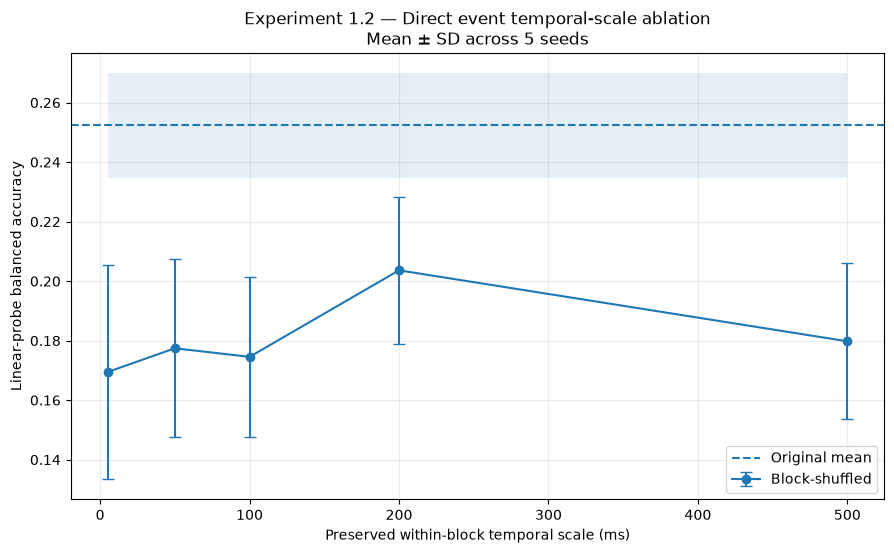

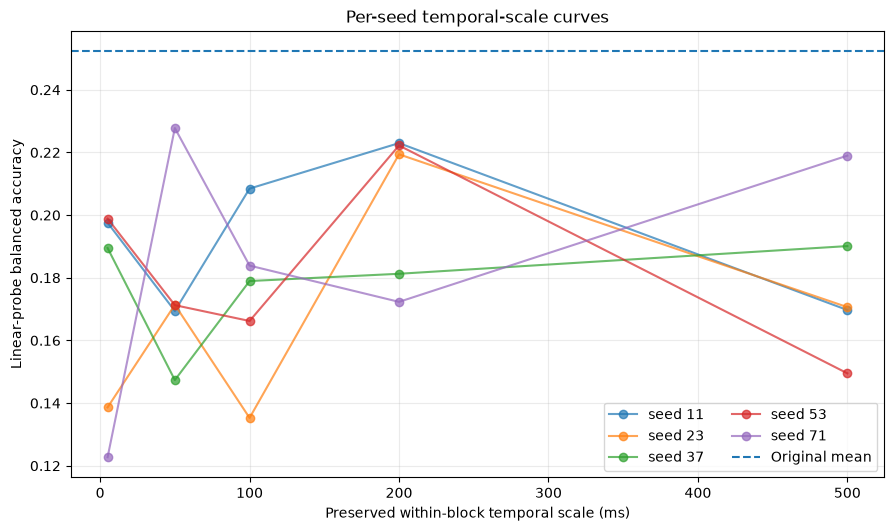

In [22]:
# Aggregate across the five seeds. The primary figure intentionally mirrors the
# frequency-benchmark convention: mean ± SD across seeds.
summary = (
    results.groupby(["condition", "preserved_ms"], dropna=False)
    .agg(
        mean_balanced_accuracy=("balanced_accuracy", "mean"),
        sd_balanced_accuracy=("balanced_accuracy", "std"),
        mean_accuracy=("accuracy", "mean"),
        mean_macro_f1=("macro_f1", "mean"),
    )
    .reset_index()
)

display(summary)

ordered = [c for c in CONDITIONS if c != "original"]
plot_rows = []
for condition in ordered:
    plot_rows.append(summary[summary.condition == condition].iloc[0])
original_row = summary[summary.condition == "original"].iloc[0]

x = np.array([float(row.preserved_ms) for row in plot_rows])
y = np.array([float(row.mean_balanced_accuracy) for row in plot_rows])
yerr = np.array([float(row.sd_balanced_accuracy) for row in plot_rows])

fig, ax = plt.subplots(figsize=(10.5, 5.8))
ax.errorbar(x, y, yerr=yerr, marker="o", capsize=4, label="Block-shuffled")
ax.axhline(float(original_row.mean_balanced_accuracy), linestyle="--", label="Original mean")
ax.fill_between(
    [x.min(), x.max()],
    float(original_row.mean_balanced_accuracy - original_row.sd_balanced_accuracy),
    float(original_row.mean_balanced_accuracy + original_row.sd_balanced_accuracy),
    alpha=0.12,
)
ax.set_xlabel("Preserved within-block temporal scale (ms)")
ax.set_ylabel("Linear-probe balanced accuracy")
ax.set_title(EXPERIMENT_TITLE + "\nMean ± SD across 5 seeds")
ax.grid(True, alpha=0.25)
ax.legend()
plt.show()

# Seed-level view: useful during review to detect a result driven by one split.
fig, ax = plt.subplots(figsize=(10.5, 5.8))
for seed in SEEDS:
    sdf = results[results.seed == seed].copy()
    xs, ys = [], []
    for condition in ordered:
        row = sdf[sdf.condition == condition].iloc[0]
        xs.append(row.preserved_ms)
        ys.append(row.balanced_accuracy)
    ax.plot(xs, ys, marker="o", alpha=0.7, label=f"seed {seed}")
ax.axhline(float(original_row.mean_balanced_accuracy), linestyle="--", label="Original mean")
ax.set_xlabel("Preserved within-block temporal scale (ms)")
ax.set_ylabel("Linear-probe balanced accuracy")
ax.set_title("Per-seed temporal-scale curves")
ax.grid(True, alpha=0.25)
ax.legend(ncol=2)
plt.show()

## Interpretation guide for the next SNN phase

- **Recovery by ~50–100 ms:** prioritize a feed-forward multi-`tau_syn` local bank; recurrence becomes a lower-priority hypothesis.
- **Recovery around ~100–300 ms:** add/test an intermediate integration mechanism after the local bank.
- **Large gap remains at 500 ms:** explicitly compare long-`tau` feed-forward memory with recurrent memory in the next phase.
- **All shuffled conditions close to Original:** temporal order is not the principal bottleneck; focus on representation/capacity before adding recurrence.

Do not read a block duration directly as an optimal `tau_syn`; the ablation identifies the scale of useful input organization, while neuron/synapse dynamics introduce their own effective receptive fields.

## Review / audit checklist

Before treating the figure as scientific evidence, verify:

1. The two configured roots are the intended Action 0 and Action 1 *combination* datasets.
2. Sampling rate, target lengths, encoder identity, and right-padding contracts pass repository validation.
3. The same five master seeds are used across all Phase-A notebooks.
4. Within a given seed, the train/val/test users do not change across temporal conditions.
5. Every shuffled condition is **retrained from scratch**; no original-trained model is merely tested on corrupted inputs.
6. Only the valid prefix is transformed; padding remains zero.
7. Joint channels move together during shuffling.
8. Mean ± SD is interpreted together with the per-seed curves; a conclusion should not be driven by one split.
9. The temporal-block curve is an information-ablation curve for this decoder, not a literal neuronal memory constant. It should guide, not mechanically dictate, later `tau_syn` or recurrence choices.
